# ARDM-style Bernoulli Imputation on MNIST with LeNet-5

In this notebook we implement a simple order-agnostic autoregressive diffusion-style model for binary MNIST images.

## Main idea

Each pixel is modeled as a Bernoulli random variable:

$$
x_i \sim \text{Bernoulli}(p_i)
$$

The neural network outputs a logit for each pixel. After applying a sigmoid, this gives the Bernoulli parameter $p_i$.

## Training procedure

For each image:
1. Sample a random order of pixels
2. Sample a random timestep \(t\)
3. Reveal the first \(t\) pixels in that order
4. Mask the remaining pixels
5. Predict Bernoulli distributions for missing pixels
6. Maximize the likelihood of the true missing pixels

## Inference procedure

Given a partially observed image:
1. Keep the observed pixels fixed
2. Sample a random order where observed pixels come first
3. Autoregressively impute missing pixels following that order
4. Update the image after each imputation step

This gives an autoregressive imputation procedure while keeping the architecture simple.

## Imports and configuration

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

Device: cpu


## Dataset: MNIST

We use the MNIST dataset of handwritten digits.

Images are:

* grayscale
* size 28x28
* normalized to [0,1]


In [2]:
class BinarizedMNIST(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        x_bin = (x > 0.5).float()
        return x, x_bin, y

In [3]:
transform = transforms.ToTensor()

train_dataset = BinarizedMNIST(
    torchvision.datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )
)

test_dataset = BinarizedMNIST(
    torchvision.datasets.MNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )
)

In [4]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Binarization of MNIST

Since we model each pixel as a Bernoulli random variable, we binarize the images.

Each pixel becomes:

* 1 if intensity > 0.5
* 0 otherwise

This allows us to use a Bernoulli likelihood and Binary Cross Entropy loss.


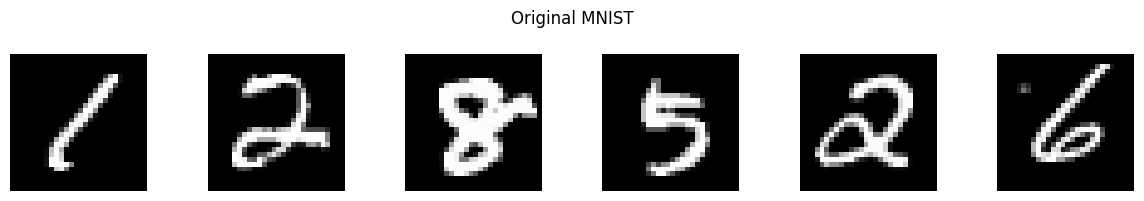

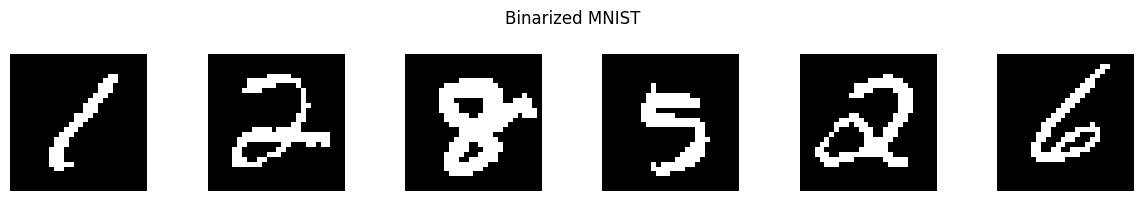

In [5]:
def show_images(images, n=6, title=None):
    images = images[:n].detach().cpu()
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    for i in range(n):
        axes[i].imshow(images[i].squeeze(), cmap="gray")
        axes[i].axis("off")
    if title is not None:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

x_batch, x_bin, y_batch = next(iter(train_loader))

show_images(x_batch, title="Original MNIST")
show_images(x_bin, title="Binarized MNIST")

## LeNet-style model

The model receives:
- the masked image
- the binary observation mask

These are concatenated as two input channels.

The network outputs one logit per pixel. Each logit parameterizes a Bernoulli distribution for that pixel.

In [6]:
class LeNetARDM(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=2, out_channels=6, kernel_size=5)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)

        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 28 * 28)

    def forward(self, x_masked, mask_obs):
        x = torch.cat([x_masked, mask_obs], dim=1)  # [B,2,28,28]

        x = self.pool(F.relu(self.conv1(x)))        # [B,6,12,12]
        x = self.pool(F.relu(self.conv2(x)))        # [B,16,4,4]

        x = x.view(x.size(0), -1)                   # [B,256]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.fc3(x)                        # [B,784]

        logits = logits.view(-1, 1, 28, 28)        # [B,1,28,28]
        return logits

In [7]:
model = LeNetARDM().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

LeNetARDM(
  (conv1): Conv2d(2, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=784, bias=True)
)


## Sampling a random order and a random timestep

For each image in the batch:
- sample a permutation of the 784 pixels
- sample a timestep t
- reveal the first t pixels in that order
- mask the rest

This gives the observed subset and the missing subset.

In [12]:
def sample_training_masks_from_random_orders(x_bin, t_min=1, t_max=None):
    """
    For each image:
    - sample a random permutation of pixels
    - sample a random t
    - reveal the first t pixels of that permutation

    Returns:
        x_masked: masked binary image
        mask_obs: observed mask (1=observed, 0=missing)
        orders: list of permutations, one per sample
        t_values: list of t values
    """
    B, C, H, W = x_bin.shape
    N = H * W

    if t_max is None:
        t_max = N - 1

    x_flat = x_bin.view(B, N)
    mask_flat = torch.zeros_like(x_flat)

    orders = []
    t_values = []

    for b in range(B):
        order = torch.randperm(N, device=x_bin.device)
        t = torch.randint(low=t_min, high=t_max + 1, size=(1,), device=x_bin.device).item()

        mask_flat[b, order[:t]] = 1.0

        orders.append(order)
        t_values.append(t)

    mask_obs = mask_flat.view(B, 1, H, W)
    x_masked = x_bin * mask_obs

    return x_masked, mask_obs, orders, t_values

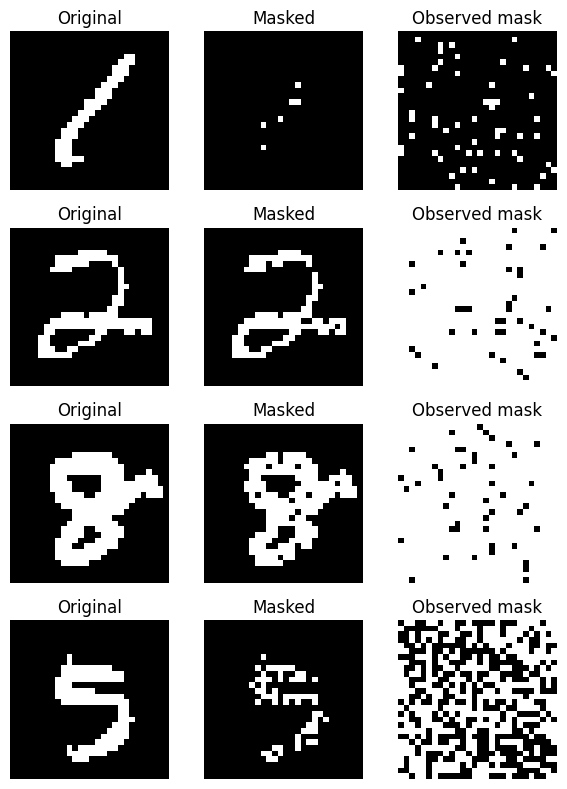

Example sampled t values: [58, 742, 739, 423, 304, 544, 623, 528]


In [13]:
x = x_batch.to(device)
x_bin = x_bin.to(device)

x_masked, mask_obs, orders, t_values = sample_training_masks_from_random_orders(x_bin)

def show_triplets(original, masked, mask, n=4):
    original = original[:n].detach().cpu()
    masked = masked[:n].detach().cpu()
    mask = mask[:n].detach().cpu()

    fig, axes = plt.subplots(n, 3, figsize=(6, 2*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        axes[i, 0].imshow(original[i].squeeze(), cmap="gray")
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masked[i].squeeze(), cmap="gray")
        axes[i, 1].set_title("Masked")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(mask[i].squeeze(), cmap="gray")
        axes[i, 2].set_title("Observed mask")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

show_triplets(x_bin, x_masked, mask_obs, n=4)
print("Example sampled t values:", t_values[:8])

## Bernoulli negative log-likelihood

The model outputs logits $z_i$ for each pixel.

These logits define Bernoulli parameters:
$
p_i = \sigma(z_i)
$

The correct negative log-likelihood for Bernoulli variables is Binary Cross Entropy.

We compute the loss only on missing pixels, because the observed pixels are already known.

In [14]:
bce_logits = nn.BCEWithLogitsLoss(reduction="none")

def masked_bernoulli_nll(logits, target, mask_obs):
    """
    logits: [B,1,28,28]
    target: [B,1,28,28] binary image
    mask_obs: [B,1,28,28] 1=observed, 0=missing

    We compute BCE only on missing pixels.
    """
    per_pixel_nll = bce_logits(logits, target) # esto nos da la loss de cada pixel, y es la NLL

    # Convertimos
    # mask_obs:     1 = observado, 0 = oculto, en 
    # missing_mask: 1 = oculto,    0 = observado
    missing_mask = 1.0 - mask_obs

    # Aquí definimos el cuántos píxeles oculté, y corresponde al D-t+1
    denom = missing_mask.sum().clamp(min=1.0)

    # la primera multiplicación es para dedir que “solo me importan los píxeles que oculté”
    loss = (per_pixel_nll * missing_mask).sum() / denom
    return loss

In [16]:
model.eval()

with torch.no_grad():
    logits = model(x_masked, mask_obs)
    loss = masked_bernoulli_nll(logits, x_bin, mask_obs)

print("Logits shape:", logits.shape)
print("Example loss:", loss.item())

Logits shape: torch.Size([64, 1, 28, 28])
Example loss: 0.6921055912971497


## Training loop

At each iteration:
1. Binarize images
2. Sample a random order and a random timestep
3. Build the observation mask
4. Predict Bernoulli logits for all pixels
5. Compute likelihood only on missing pixels
6. Backpropagate

In [18]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    for _, x_bin,_ in loader:
        x_bin = x_bin.to(device)

        x_masked, mask_obs, _, _ = sample_training_masks_from_random_orders(x_bin)

        optimizer.zero_grad()

        logits = model(x_masked, mask_obs)
        loss = masked_bernoulli_nll(logits, x_bin, mask_obs)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [19]:
@torch.no_grad()
def evaluate_one_epoch(model, loader, device):
    model.eval()
    running_loss = 0.0

    for _, x_bin ,_ in loader:
        x_bin = x_bin.to(device)

        x_masked, mask_obs, _, _ = sample_training_masks_from_random_orders(x_bin)

        logits = model(x_masked, mask_obs)
        loss = masked_bernoulli_nll(logits, x_bin, mask_obs)

        running_loss += loss.item()

    return running_loss / len(loader)

In [20]:
num_epochs = 10

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    test_loss = evaluate_one_epoch(model, test_loader, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f"Epoch {epoch+1:02d} | train NLL: {train_loss:.4f} | test NLL: {test_loss:.4f}")

Epoch 01 | train NLL: 0.2468 | test NLL: 0.1955
Epoch 02 | train NLL: 0.1809 | test NLL: 0.1696
Epoch 03 | train NLL: 0.1635 | test NLL: 0.1557
Epoch 04 | train NLL: 0.1546 | test NLL: 0.1494
Epoch 05 | train NLL: 0.1490 | test NLL: 0.1445
Epoch 06 | train NLL: 0.1443 | test NLL: 0.1425
Epoch 07 | train NLL: 0.1416 | test NLL: 0.1400
Epoch 08 | train NLL: 0.1388 | test NLL: 0.1377
Epoch 09 | train NLL: 0.1369 | test NLL: 0.1347
Epoch 10 | train NLL: 0.1350 | test NLL: 0.1338


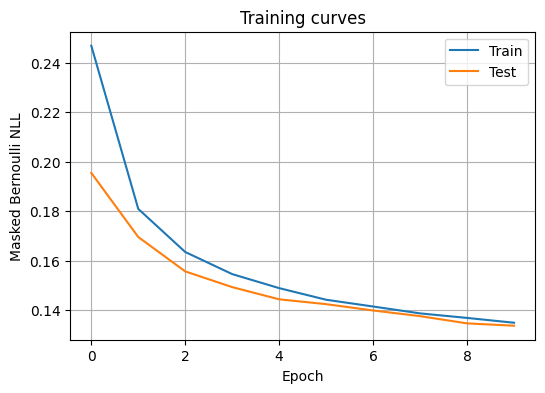

In [21]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Masked Bernoulli NLL")
plt.title("Training curves")
plt.legend()
plt.grid(True)
plt.show()

## One-shot imputation

As a baseline, we first impute all missing pixels in one forward pass.

This is not autoregressive yet, but it is useful as a comparison.

In [22]:
@torch.no_grad()
def one_shot_impute(model, x_masked, mask_obs, stochastic=False):
    model.eval()

    logits = model(x_masked, mask_obs)
    probs = torch.sigmoid(logits)

    if stochastic:
        x_pred = torch.bernoulli(probs)
    else:
        x_pred = (probs > 0.5).float()

    x_imputed = x_masked.clone()
    missing_mask = (mask_obs == 0)
    x_imputed[missing_mask] = x_pred[missing_mask]

    return x_imputed, probs

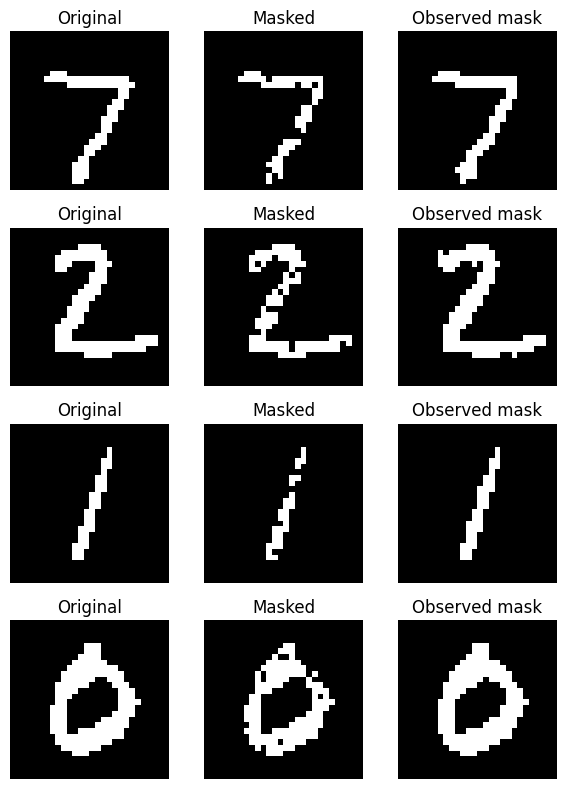

In [23]:
x_test,x_test_bin, _ = next(iter(test_loader))
x_test = x_test.to(device)
x_test_bin = x_test_bin.to(device)

x_masked, mask_obs, _, _ = sample_training_masks_from_random_orders(x_test_bin)

x_one_shot, probs = one_shot_impute(model, x_masked, mask_obs, stochastic=False)

show_triplets(x_test_bin, x_masked, x_one_shot, n=4)

## Autoregressive inference

Now we implement the autoregressive imputation procedure.

Given a partially observed image:
1. Keep observed pixels fixed
2. Build a random order where observed pixels come first
3. The missing pixels are placed afterwards in random order
4. We reveal missing pixels progressively following that order
5. After each step, the updated image is fed back to the network

This allows the model to use increasing context over time.

In [24]:
def build_inference_orders_from_mask(mask_obs):
    """
    For each image:
    - observed pixel indices come first
    - missing pixel indices come after, in random order

    Returns a list of full orders.
    """
    B, C, H, W = mask_obs.shape
    N = H * W
    mask_flat = mask_obs.view(B, N)

    orders = []

    for b in range(B):
        observed_idx = torch.where(mask_flat[b] == 1)[0]
        missing_idx = torch.where(mask_flat[b] == 0)[0]

        if len(observed_idx) > 0:
            observed_idx = observed_idx[torch.randperm(len(observed_idx), device=mask_obs.device)]
        if len(missing_idx) > 0:
            missing_idx = missing_idx[torch.randperm(len(missing_idx), device=mask_obs.device)]

        full_order = torch.cat([observed_idx, missing_idx], dim=0)
        orders.append(full_order)

    return orders

In [25]:
def random_observation_mask(x_bin, p_observed=0.3):
    """
    Independent random observation mask for inference experiments.
    """
    mask_obs = (torch.rand_like(x_bin) < p_observed).float()
    x_masked = x_bin * mask_obs
    return x_masked, mask_obs

In [26]:
@torch.no_grad()
def autoregressive_impute(
    model,
    x_masked,
    mask_obs,
    orders,
    step_size=50,
    stochastic=True,
    return_history=False
):
    """
    Autoregressive imputation using a precomputed order.

    Parameters
    ----------
    x_masked : partially observed image
    mask_obs : observed mask
    orders   : list of orders, one per image
    step_size: how many new pixels to impute per iteration
    stochastic: if True sample Bernoulli; otherwise threshold at 0.5
    """
    model.eval()

    B, C, H, W = x_masked.shape
    N = H * W

    x_current = x_masked.clone()
    mask_current = mask_obs.clone()

    history = [x_current.clone()] if return_history else None

    x_flat = x_current.view(B, N)
    mask_flat = mask_current.view(B, N)

    # For each sample, find where the missing part starts in the order
    start_positions = []
    for b in range(B):
        num_observed = int(mask_flat[b].sum().item())
        start_positions.append(num_observed)

    finished = [False] * B

    while not all(finished):
        logits = model(x_current, mask_current)
        probs = torch.sigmoid(logits).view(B, N)

        for b in range(B):
            if finished[b]:
                continue

            order = orders[b]
            start = start_positions[b]

            next_end = min(start + step_size, N)
            chosen_idx = order[start:next_end]

            if len(chosen_idx) == 0:
                finished[b] = True
                continue

            if stochastic:
                sampled = torch.bernoulli(probs[b, chosen_idx])
            else:
                sampled = (probs[b, chosen_idx] > 0.5).float()

            x_flat[b, chosen_idx] = sampled
            mask_flat[b, chosen_idx] = 1.0

            start_positions[b] = next_end
            if next_end >= N:
                finished[b] = True

        x_current = x_flat.view(B, 1, H, W)
        mask_current = mask_flat.view(B, 1, H, W)

        if return_history:
            history.append(x_current.clone())

    if return_history:
        return x_current, mask_current, history
    return x_current, mask_current

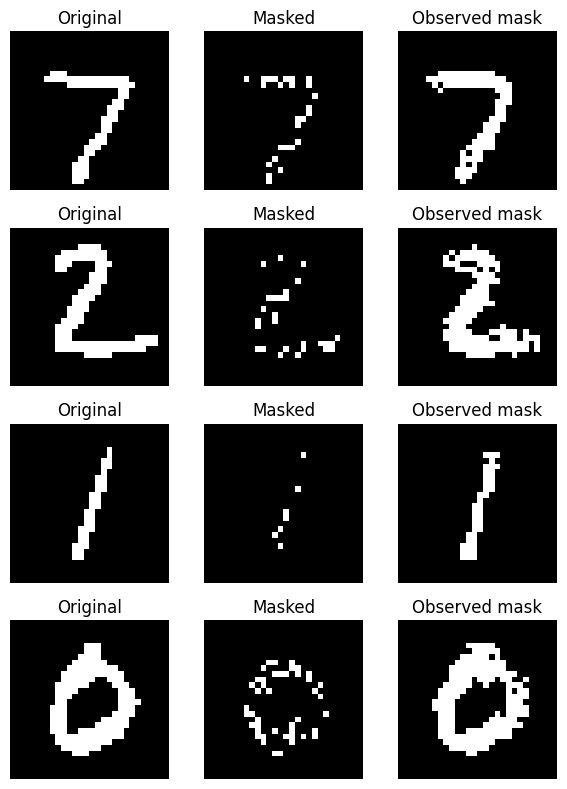

In [27]:
x_test,x_test_bin, _ = next(iter(test_loader))
x_test = x_test.to(device)
x_test_bin = x_test_bin.to(device)

x_masked_inf, mask_obs_inf = random_observation_mask(x_test_bin, p_observed=0.25)
orders_inf = build_inference_orders_from_mask(mask_obs_inf)

x_auto, final_mask, history = autoregressive_impute(
    model,
    x_masked_inf,
    mask_obs_inf,
    orders_inf,
    step_size=40,
    stochastic=True,
    return_history=True
)

show_triplets(x_test_bin, x_masked_inf, x_auto, n=4)

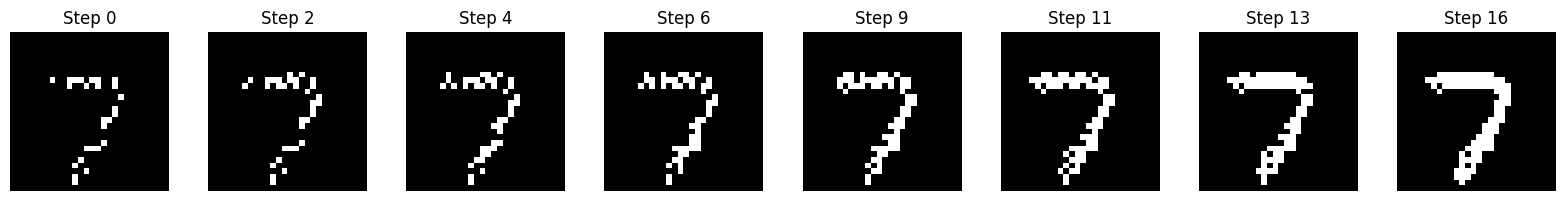

In [28]:
def show_history(history, sample_idx=0, max_panels=8):
    n_steps = len(history)
    chosen = np.linspace(0, n_steps - 1, min(n_steps, max_panels), dtype=int)

    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2))
    if len(chosen) == 1:
        axes = [axes]

    for ax, t in zip(axes, chosen):
        ax.imshow(history[t][sample_idx].detach().cpu().squeeze(), cmap="gray")
        ax.set_title(f"Step {t}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_history(history, sample_idx=0, max_panels=8)

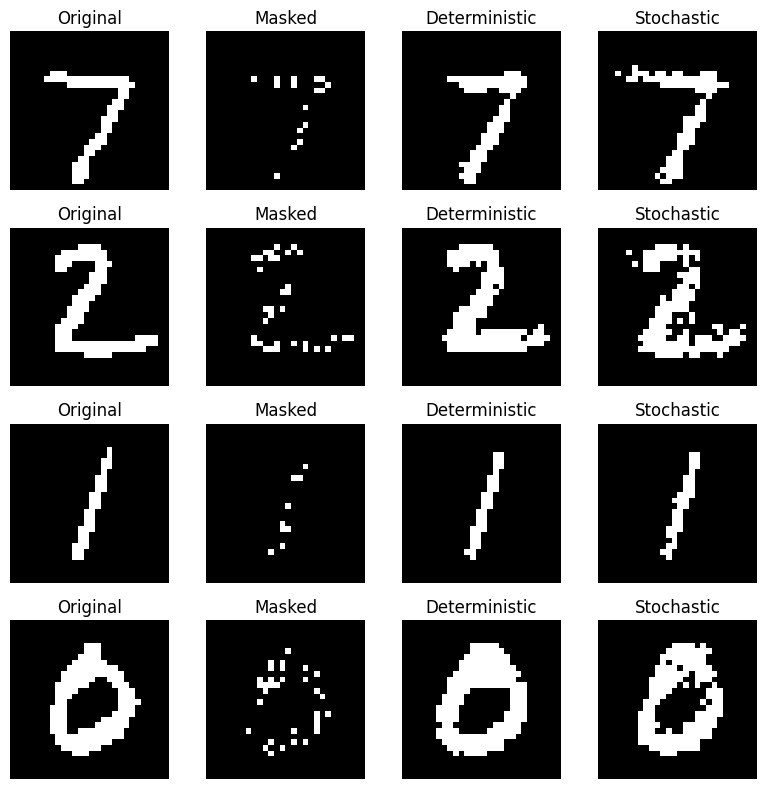

In [29]:
x_test,x_test_bin, _ = next(iter(test_loader))
x_test = x_test.to(device)
x_test_bin = x_test_bin.to(device)

x_masked_inf, mask_obs_inf = random_observation_mask(x_test_bin, p_observed=0.25)
orders_inf = build_inference_orders_from_mask(mask_obs_inf)

x_det, _ = autoregressive_impute(
    model,
    x_masked_inf,
    mask_obs_inf,
    orders_inf,
    step_size=40,
    stochastic=False,
    return_history=False
)

x_sto, _ = autoregressive_impute(
    model,
    x_masked_inf,
    mask_obs_inf,
    orders_inf,
    step_size=40,
    stochastic=True,
    return_history=False
)

def show_four(original, masked, det, sto, n=4):
    fig, axes = plt.subplots(n, 4, figsize=(8, 2*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        axes[i,0].imshow(original[i].detach().cpu().squeeze(), cmap="gray")
        axes[i,0].set_title("Original")
        axes[i,0].axis("off")

        axes[i,1].imshow(masked[i].detach().cpu().squeeze(), cmap="gray")
        axes[i,1].set_title("Masked")
        axes[i,1].axis("off")

        axes[i,2].imshow(det[i].detach().cpu().squeeze(), cmap="gray")
        axes[i,2].set_title("Deterministic")
        axes[i,2].axis("off")

        axes[i,3].imshow(sto[i].detach().cpu().squeeze(), cmap="gray")
        axes[i,3].set_title("Stochastic")
        axes[i,3].axis("off")

    plt.tight_layout()
    plt.show()

show_four(x_test_bin, x_masked_inf, x_det, x_sto, n=4)

In [30]:
@torch.no_grad()
def missing_pixel_accuracy(x_true, x_pred, mask_obs):
    missing = (mask_obs == 0)
    correct = (x_true == x_pred).float()
    acc = correct[missing].mean().item()
    return acc

In [31]:
x_test,x_test_bin, _ = next(iter(test_loader))
x_test = x_test.to(device)
x_test_bin = x_test_bin.to(device)

x_masked_inf, mask_obs_inf = random_observation_mask(x_test_bin, p_observed=0.25)
orders_inf = build_inference_orders_from_mask(mask_obs_inf)

x_one_shot, _ = one_shot_impute(model, x_masked_inf, mask_obs_inf, stochastic=False)
x_auto_det, _ = autoregressive_impute(
    model,
    x_masked_inf,
    mask_obs_inf,
    orders_inf,
    step_size=40,
    stochastic=False
)

acc_one_shot = missing_pixel_accuracy(x_test_bin, x_one_shot, mask_obs_inf)
acc_auto_det = missing_pixel_accuracy(x_test_bin, x_auto_det, mask_obs_inf)

print(f"One-shot missing-pixel accuracy:      {acc_one_shot:.4f}")
print(f"Autoregressive missing-pixel accuracy:{acc_auto_det:.4f}")

One-shot missing-pixel accuracy:      0.9429
Autoregressive missing-pixel accuracy:0.9394
